# Run checks on assembled dataset

Although we run assemble again in each notebook, the AssembleDataset class has some sanity check methods which I prefer to keep them. 

Use flattened data generated by `run/run_ml_prep.py`, where `run` is a string which indicates which round of processing was using (cuts/flattening technique)

This is a good place to make misc plots as well.


In [1]:
!pwd

/home/mu2ecrv/sgrant-ana/mu2e-cosmic/notebooks/ml/xgboost


In [2]:
import sys
sys.path.append("../../../src/ml")

In [3]:
run = "k"
from assemble import AssembleDataset
asm = AssembleDataset(run=run)
help(asm)

[LoadML] [OK] Initialised
[Load] [OK] Initialised with out_path=/home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw/results.pkl
[Load] [OK] Initialised with out_path=/home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw/results.pkl
[LoadML] [OK] Got full results
[Assemble] [OK] Loaded data
[Assemble] [OK] Initialised
Help on AssembleDataset in module assemble object:

class AssembleDataset(builtins.object)
 |  AssembleDataset(run='j', cutset_name='dev', verbosity=1)
 |
 |  Load, label, and split CRY/CE mix data for ML training.
 |
 |  Methods defined here:
 |
 |  __init__(self, run='j', cutset_name='dev', verbosity=1)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  assemble_dat

In [4]:
asm.check_dT_window_results()

,Metric,CRY,CE Mix
0,Total,20087,578368
1,Unvetoed,10,417011
2,Fraction [%],99.95,27.90


In [5]:
df = asm.check_dT_window_results()
df.to_csv("baseline_dT_results.csv", index=False)

In [6]:
# print(data["y"].value_counts())


[Load] [OK] Initialised with out_path=test_out
[pyprint] [INFO] Initialised Print with verbose = False and precision = 1
[Plot] [INFO] Initialised
[Plot] [OK] 	Wrote /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/k/process/h1o_3x3_cuts_CRY.png


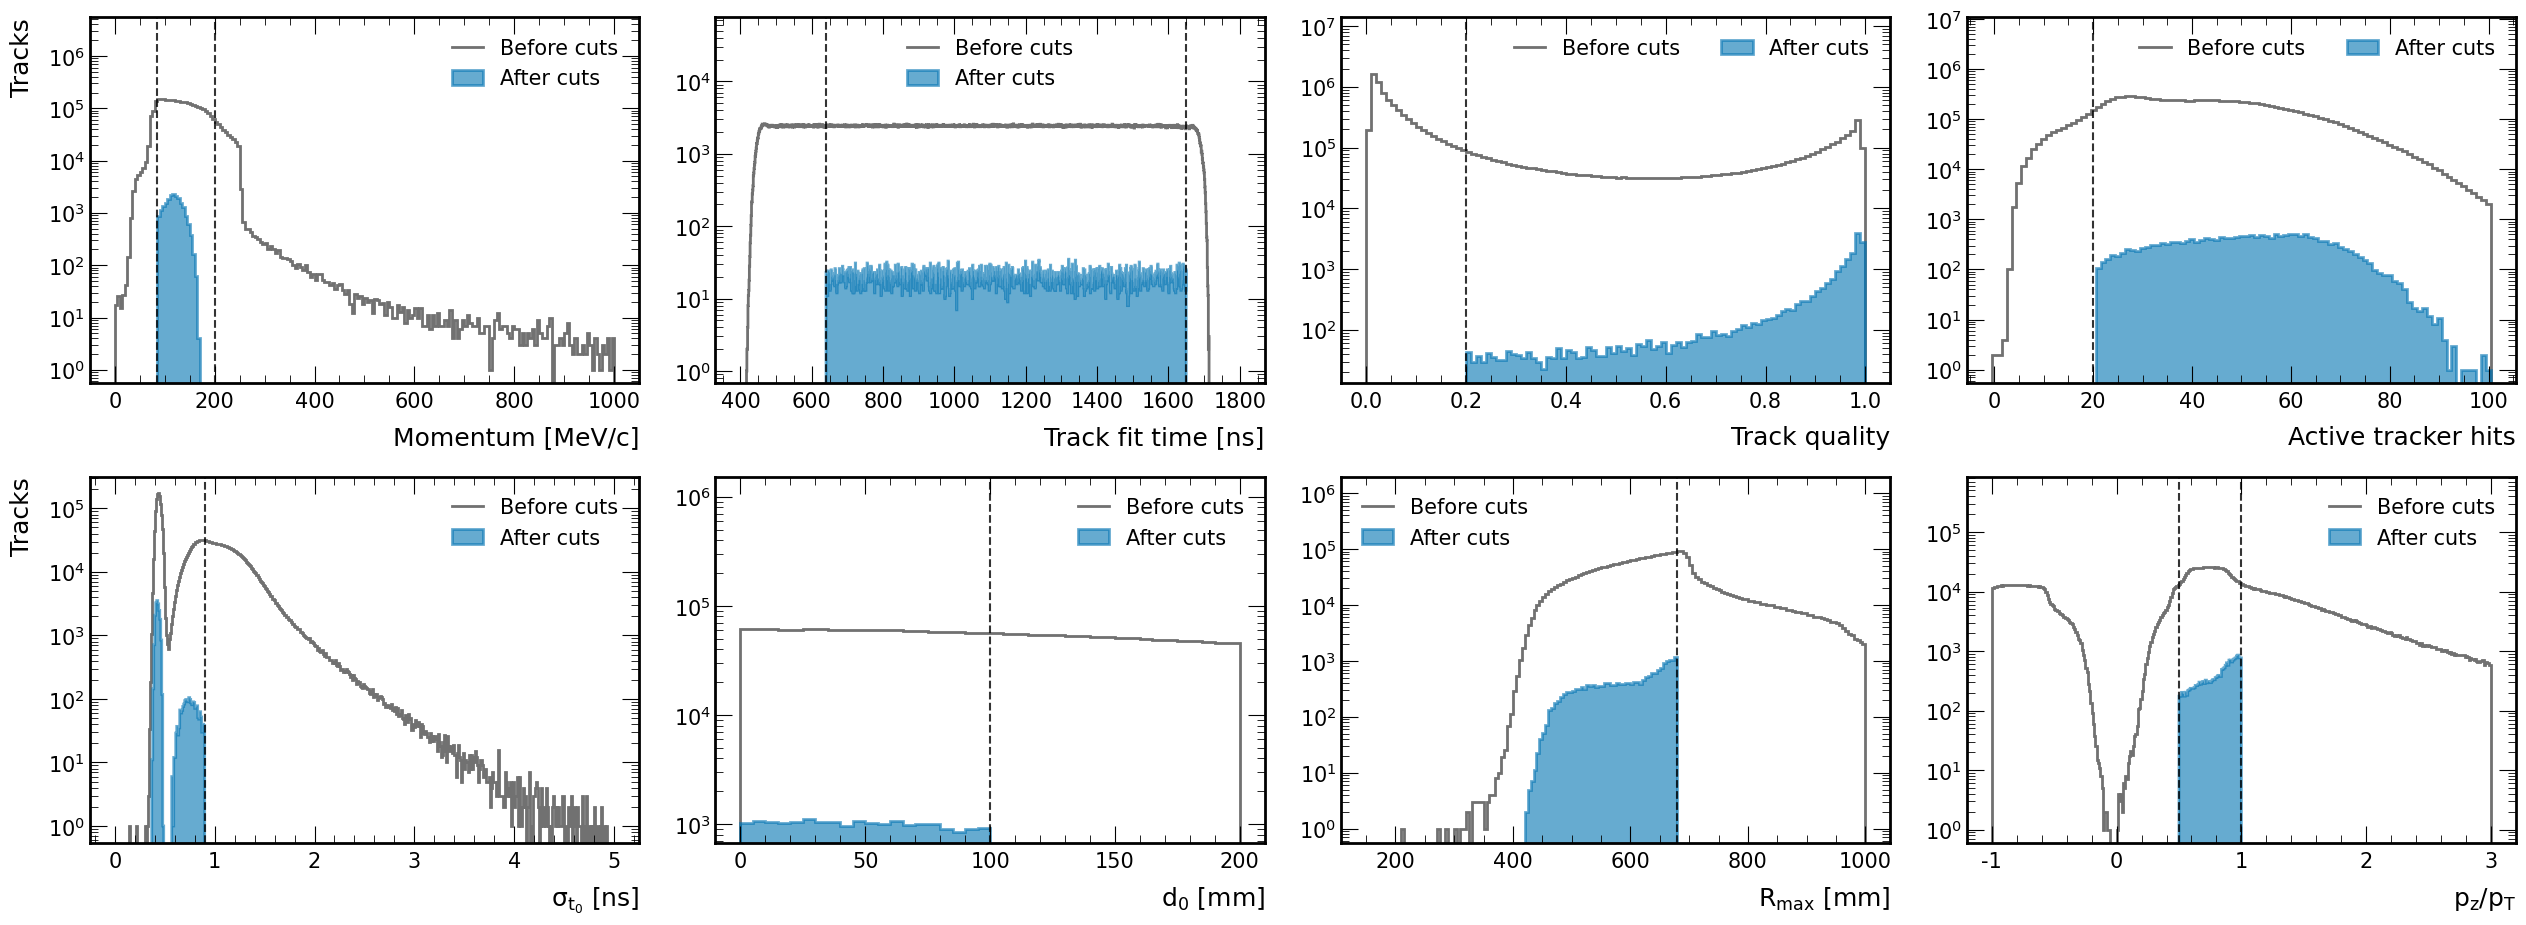

[Plot] [OK] 	Wrote /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/k/process/h1o_3x3_cuts_CE_mix.png


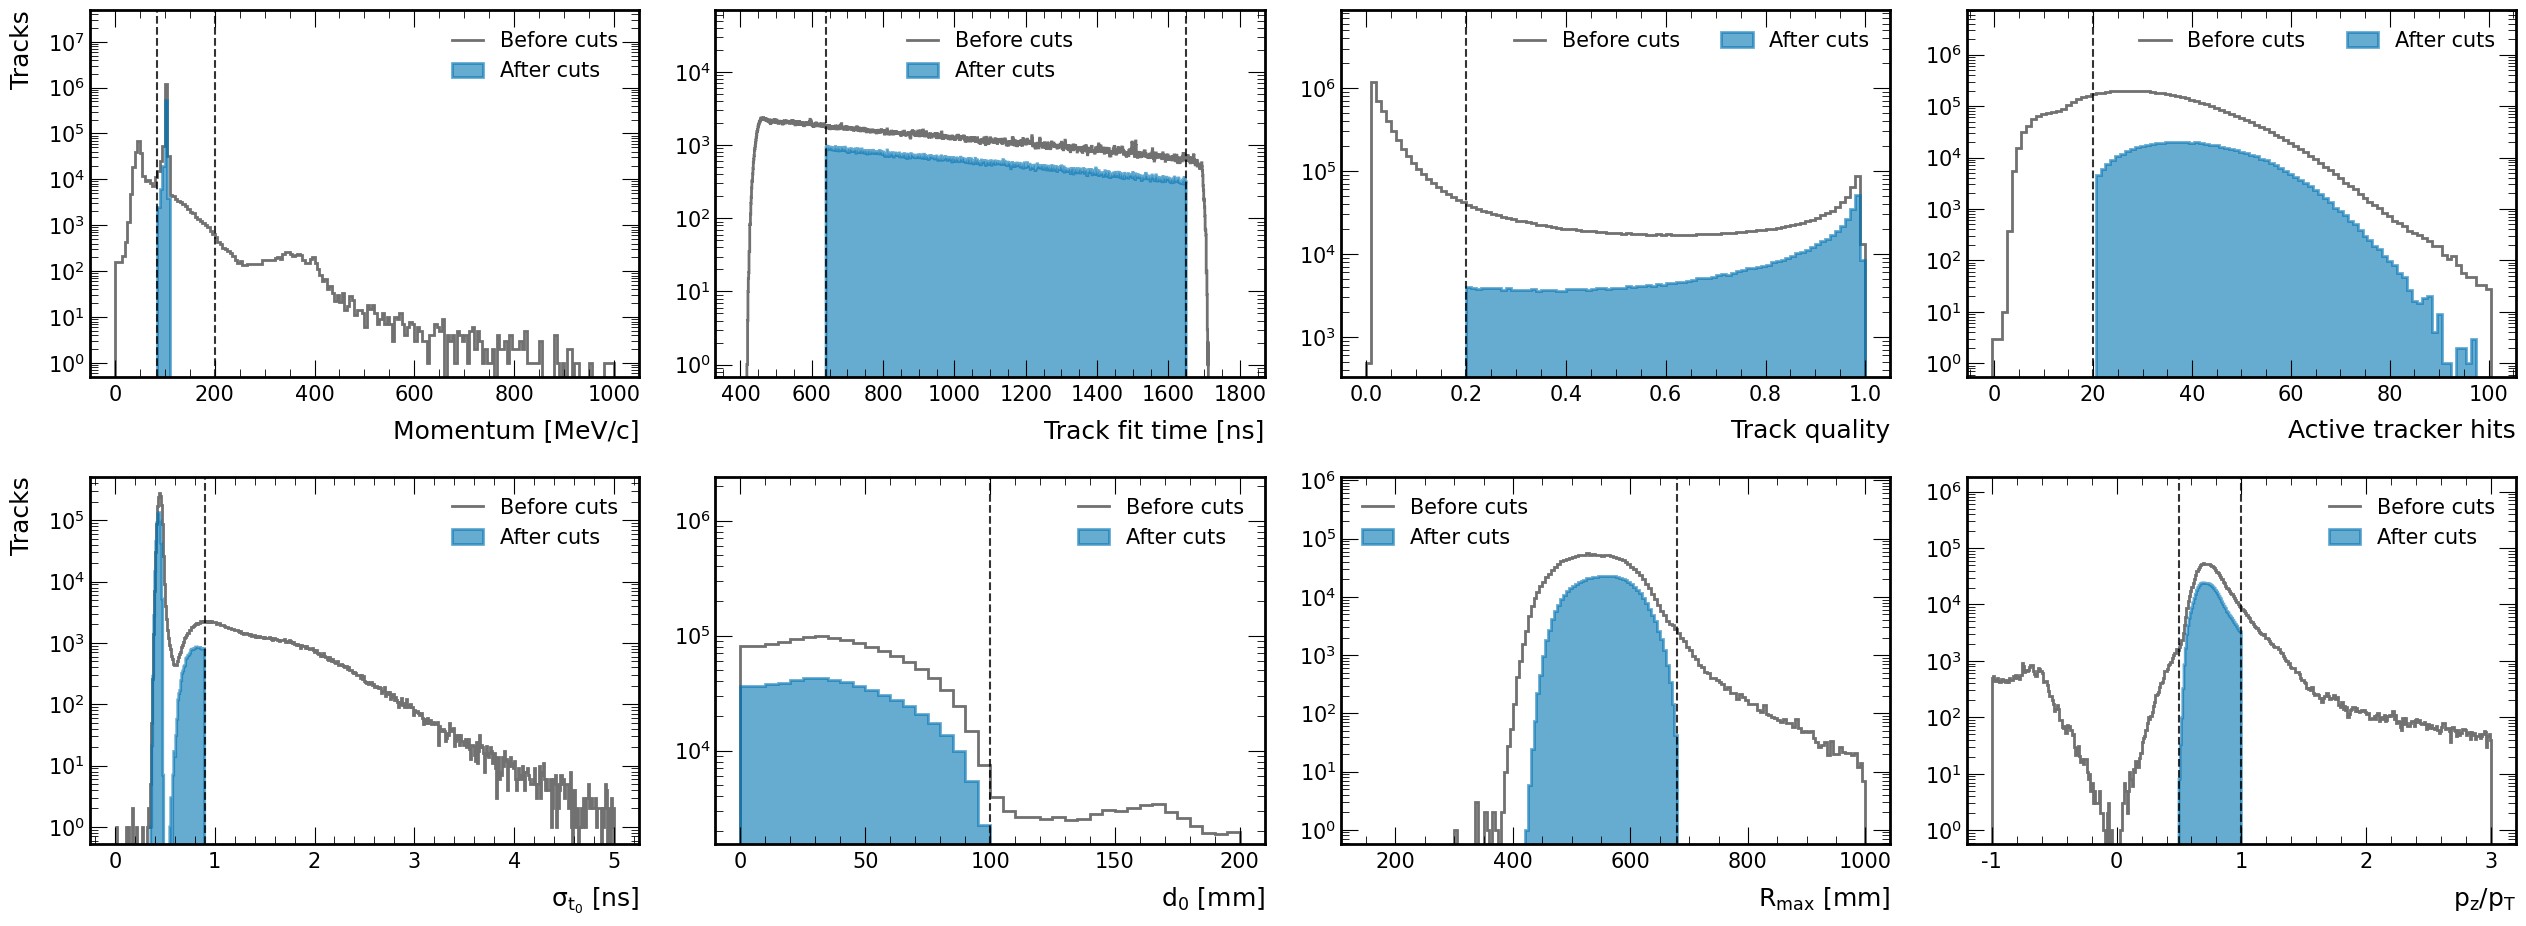

In [7]:
asm.draw_cuts(ml=True)

[Assemble] [OK] Saved feature distributions to /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/k/process/h1o_2x4_crv_features.png


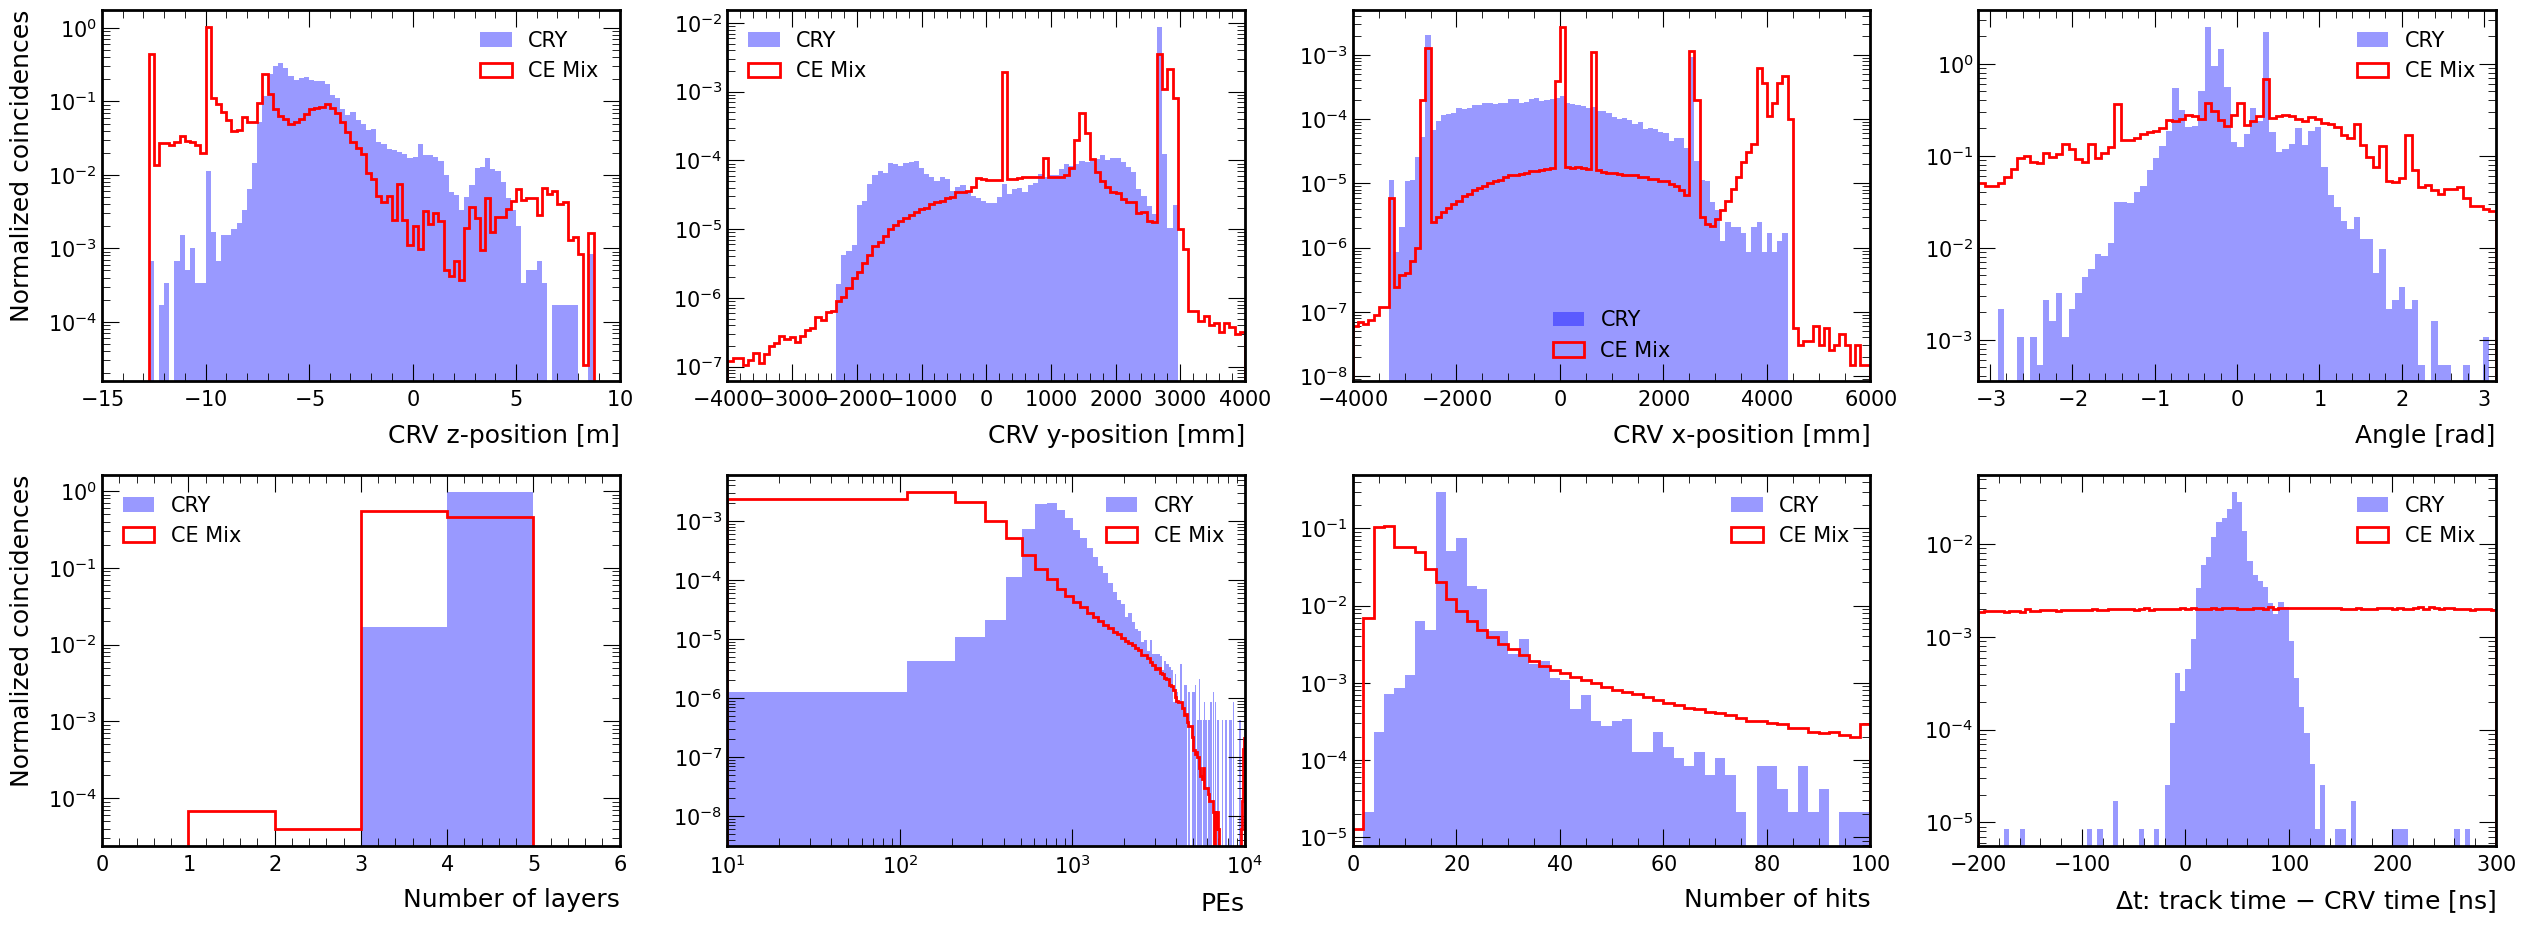

In [8]:
asm.draw_features()

In [9]:
cut_flows = asm.get_cut_flows()
for name, cut_flow in cut_flows.items():
    print(f"{name}:")
    display(cut_flow)

cry:


,Cut,Group,Events Passing,Absolute [%],Relative [%],Description
0,No cuts,NaN,2610933,100.000,100.000,No selection applied
1,thru_trk,Preselect,2528178,96.830,96.830,Tracks intersect full tracker
2,is_reco_electron,Preselect,2447193,93.729,96.797,Select electron track hypothesis
3,one_reco_electron,Preselect,2020330,77.380,82.557,One reco electron / event
4,is_downstream,Preselect,1111321,42.564,55.007,Downstream tracks (p_z > 0 through tracker)
5,is_truth_electron,Preselect,320059,12.258,28.800,Track parents are electrons (truth PID)
6,good_trkqual,Tracker,253908,9.725,79.332,Track quality > 0.2
7,within_t0,Tracker,203298,7.786,80.068,t0 at tracker mid (640 < t_0 < 1650 ns)
8,within_t0err,Tracker,188693,7.227,92.816,Track fit t0 uncertainty (t0err < 0.9 ns)
9,has_hits,Tracker,186108,7.128,98.630,>20 active tracker hits


ce_mix:


,Cut,Group,Events Passing,Absolute [%],Relative [%],Description
0,No cuts,NaN,1339362,100.000,100.000,No selection applied
1,thru_trk,Preselect,1336977,99.822,99.822,Tracks intersect full tracker
2,is_reco_electron,Preselect,1327509,99.115,99.292,Select electron track hypothesis
3,one_reco_electron,Preselect,1097120,81.914,82.645,One reco electron / event
4,is_downstream,Preselect,1096121,81.839,99.909,Downstream tracks (p_z > 0 through tracker)
5,is_truth_electron,Preselect,1096052,81.834,99.994,Track parents are electrons (truth PID)
6,good_trkqual,Tracker,883129,65.937,80.574,Track quality > 0.2
7,within_t0,Tracker,655442,48.937,74.218,t0 at tracker mid (640 < t_0 < 1650 ns)
8,within_t0err,Tracker,636325,47.510,97.083,Track fit t0 uncertainty (t0err < 0.9 ns)
9,has_hits,Tracker,621990,46.439,97.747,>20 active tracker hits


In [10]:
cut_flows["cry"].to_csv("cut_flow.csv", index=False)

In [11]:
data = asm.assemble_dataset()

[Assemble] [OK] Prepared 5-fold nested CV (event-level grouping)
  Total: 2163528 coincidences
  Fold test sizes: [432706, 432706, 432706, 432705, 432705]


In [12]:
print(data["y"].value_counts())
print(data["y"].value_counts()[0]/data["y"].value_counts()[1])

label
0    2139801
1      23727
Name: count, dtype: int64
90.1842205082817


In [13]:
data["df_full"]

,event,subrun,crv_x,crv_y,crv_z,PEs,dT,nHits,nLayers,angle,timeStart,timeEnd,sector,PEs_per_hit,t0,d0,tanDip,maxr,mom_mag,label
0,2650.0,98.0,-4.547474e-13,2684.661133,-7921.097656,90.724777,527.722271,4.0,3.0,0.727466,525.451538,587.951538,3.0,22.681194,1016.454419,42.117722,0.583941,617.263550,103.368034,0
1,1859.0,843.0,4.071482e+03,2862.049561,-9957.799805,285.257233,-805.731684,10.0,4.0,1.353849,1607.101807,1782.101807,4.0,28.525723,786.035162,32.673702,0.605967,602.773804,103.583145,0
2,2192.0,457.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1096.057591,8.055742,0.715509,539.576172,104.595360,0
3,556.0,411.0,6.362000e+02,1513.145508,-12567.080078,34580.207031,-397.368187,1899.0,4.0,-1.526525,412.966553,1787.966553,5.0,18.209693,661.050758,24.049637,0.879215,526.783875,104.189644,0
4,2974.0,707.0,0.000000e+00,2731.275635,-12267.968750,240.338318,-22.465829,8.0,4.0,-3.002133,983.740662,1146.240723,3.0,30.042290,1019.720328,65.952957,0.743986,470.854187,104.093399,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163523,3061.0,925.0,3.952777e+01,2711.051514,-7511.345703,131.810699,782.745075,12.0,3.0,-1.497381,742.005493,842.005493,3.0,10.984225,1500.949542,74.319374,0.665570,633.117065,104.378433,0
2163524,3076.0,722.0,0.000000e+00,2681.962402,-2549.654053,86.194878,-311.175052,5.0,3.0,3.386727,1285.348145,1447.848145,3.0,17.238976,983.938596,30.310881,0.856973,541.797424,104.623466,0
2163525,2061.0,331.0,0.000000e+00,2701.172852,-11403.797852,260.580322,678.858792,11.0,4.0,-0.721829,716.635193,891.635193,3.0,23.689120,1384.573697,65.948845,0.930326,555.570496,104.027061,0
2163526,2004.0,40.0,-2.573767e+03,-934.724060,-4733.690430,200.804611,-146.186658,12.0,3.0,-1.477709,1139.843506,1252.343506,1.0,16.733718,976.955921,28.302200,0.711944,516.766479,103.907005,0


In [14]:
cols = ["event", "subrun", "PEs", "dT", "nHits", "crv_z", "angle", "crv_x", "crv_y", "nLayers", "label"]
df = data["df_full"][cols][data["df_full"]["label"]==1]
display(df)

,event,subrun,PEs,dT,nHits,crv_z,angle,crv_x,crv_y,nLayers,label
140,87625.0,41988.0,878.959717,43.955147,16.0,-6147.793457,-0.410212,604.325256,2705.346436,4.0,1
210,138516.0,26117.0,880.353516,48.982808,16.0,-3588.013184,-0.325533,-2585.590576,1575.125122,4.0,1
222,395786.0,426.0,598.232361,56.394356,22.0,-2974.029785,0.013093,910.385193,2707.904785,4.0,1
266,151734.0,2325.0,825.234375,36.065351,16.0,-5295.029297,-0.674409,-1614.841309,2702.555176,4.0,1
374,17688.0,3895.0,730.391541,38.479597,17.0,-6355.976562,-0.412615,-468.313171,2707.836426,4.0,1
...,...,...,...,...,...,...,...,...,...,...,...
2163141,123668.0,10984.0,830.904663,51.340792,18.0,-6875.591309,-0.433142,1099.154419,2707.906738,4.0,1
2163187,27030.0,32367.0,691.808167,55.815986,16.0,-6071.390137,0.325729,721.309570,2713.407959,4.0,1
2163221,439885.0,10277.0,633.933105,60.822633,16.0,-3435.709961,-0.328242,-2578.015381,2412.075928,4.0,1
2163396,336185.0,76081.0,1353.680908,33.392916,34.0,-5278.848145,-1.307007,-1075.785767,2718.874756,4.0,1


In [15]:
#from pyutils.pyplot imdataport Plot
#plotter = Plot()
#import matplotlib.pyplot as plt 

#fig, ax = plt.subplots(1,3,figsize=(3*6.4, 4.8))

#plotter.plot_1D_overlay(
    #{
        #"CE Mix" : data["df_full"]["timeStart"][data["df_full"]["label"]==0],
        #"CRY" : data["df_full"]["timeStart"][data["df_full"]["label"]==1],
    #},
    #nbins = 210,
    #xmin = 0,
    #xmax = 2100,
    #show=False,
    #norm_by_area=True,
    #ylabel="Normalized coincidences",
    #xlabel="Start time [ns]",
    #ax=ax[0]
#)

#plotter.plot_1D_overlay(
    #{
        #"CE Mix" : data["df_full"]["timeEnd"][data["df_full"]["label"]==0],
        #"CRY" : data["df_full"]["timeEnd"][data["df_full"]["label"]==1],
    #},
    #nbins = 210,
    #xmin = 0,
    #xmax = 2100,
    #show=False,
    #norm_by_area=True,
    #ylabel="Normalized coincidences",
    #xlabel="End time [ns]",
    #ax=ax[1]
#)

#data["df_full"]["duration"] = data["df_full"]["timeEnd"] - data["df_full"]["timeStart"] 

#plotter.plot_1D_overlay(
    #{
        #"CE Mix" : data["df_full"]["duration"][data["df_full"]["label"]==0],
        #"CRY" : data["df_full"]["duration"][data["df_full"]["label"]==1],
    #},
    #nbins = 150,
    #xmin = 0,
    #xmax = 1500,
    #show=False,
    #norm_by_area=True,
    #log_y=True,
    #ylabel="Normalized coincidences",
    #xlabel="Duration [ns]",
    #ax=ax[2]
#)

#plt.tight_layout()

#out_name = asm.img_out_path / "h1o_1x3_coinc_time.png" 
#plt.savefig(out_name, dpi=300)
#plt.show()